# Notebook 3: Explainability and SHAP Analysis

**Objective:** Audit the importance of physiological variables (systemic load, volume, etc.) using the SHAP library. Provide local and global interpretability visualizations. 

In [2]:
%pip install shap

  Using cached numba-0.65.1-cp312-cp312-win_amd64.whl.metadata (3.0 kB)
   ---------------------------------------- 0.0/499.9 kB ? eta -:--:--
    --------------------------------------- 10.2/499.9 kB ? eta -:--:--
   --------- ------------------------------ 122.9/499.9 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------  491.5/499.9 kB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 499.9/499.9 kB 3.1 MB/s eta 0:00:00
Using cached numba-0.65.1-cp312-cp312-win_amd64.whl (2.8 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
#Load the model and test data
import joblib
import pandas as pd

# Load everything back into memory exactly as it was!
xgb_model = joblib.load("../data/processed/xgb_baseline_model.pkl")

X_test = pd.read_pickle("../data/processed/X_test.pkl")
# ... (load the rest if needed)


## 1. SHAP Explainer Initialization


Calculating SHAP values...
Calculation complete!


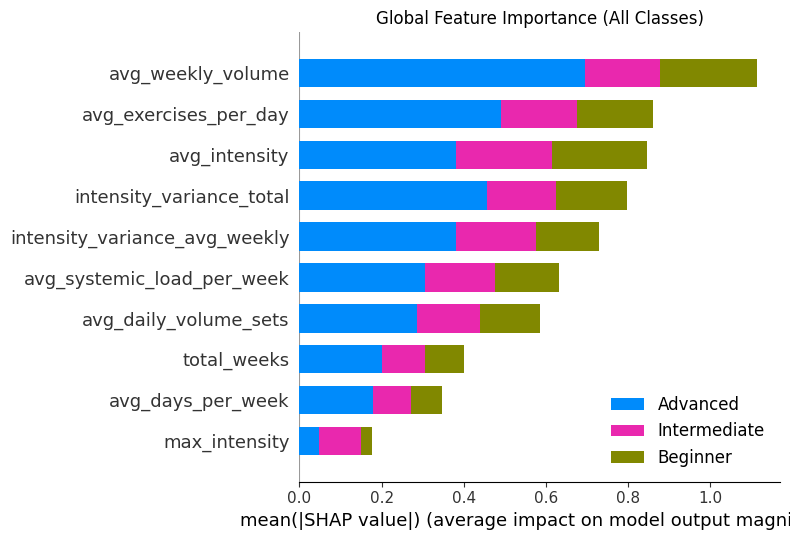

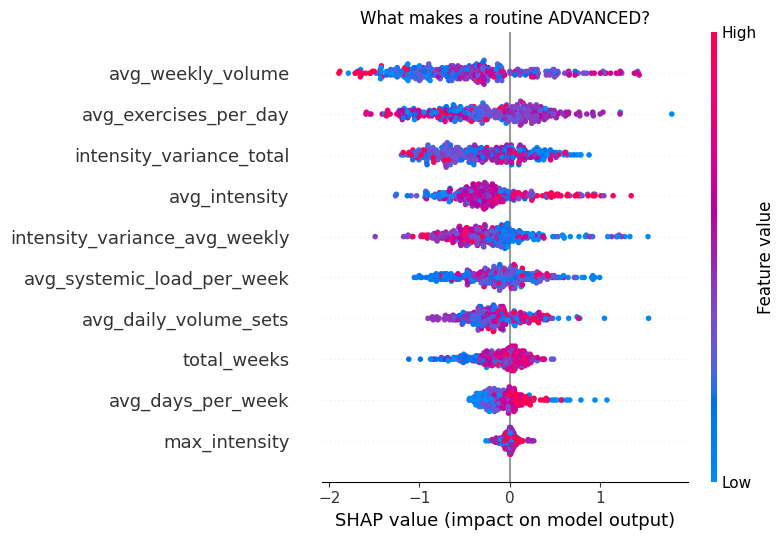

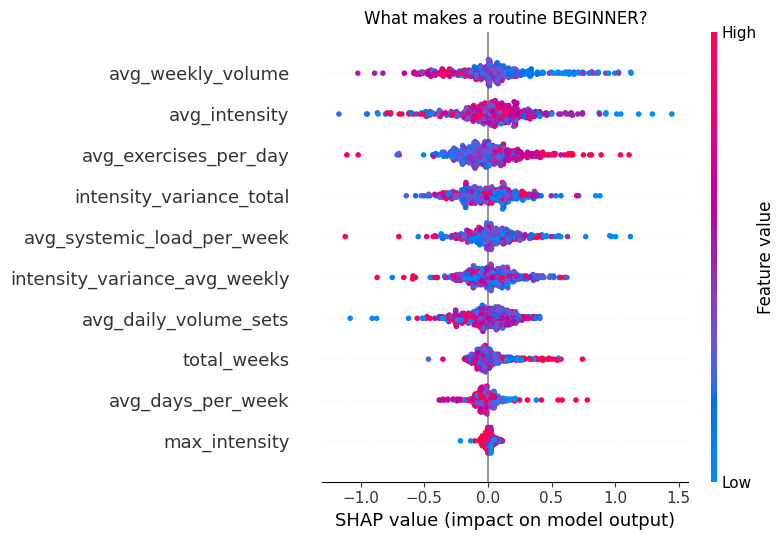

In [8]:
import shap
import matplotlib.pyplot as plt

shap.initjs()

# 1. Initialize the Explainer
explainer = shap.TreeExplainer(xgb_model)

# 2. Use the Classic API: .shap_values()
# For your 3 classes, this guarantees it returns a clean Python list of 3 arrays
print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_test)
print("Calculation complete!")

# ---------------------------------------------------------
# PLOT 1: Global Bar Chart (Stacked Multiclass)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.title("Global Feature Importance (All Classes)")
# The classic summary_plot accepts the list perfectly and stacks the colors!
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type="bar", 
    class_names=["Beginner", "Intermediate", "Advanced"]
)

# ---------------------------------------------------------
# PLOT 2: Advanced Routines Only (Dot Plot)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.title("What makes a routine ADVANCED?")
shap.summary_plot(shap_values[:, :, 2], X_test)
# ---------------------------------------------------------
# PLOT 3: Beginner Routines Only (Dot Plot)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.title("What makes a routine BEGINNER?")
shap.summary_plot(shap_values[:,:,0], X_test)

## 2. Global Interpretability (Feature Importance)

The Summary Plot shows the overall impact of features across the entire dataset. It highlights which physiological attributes the network relies on most.

In [ ]:
# Calculate SHAP values for a sample of the test set
# sample_size = 500
# test_sample = X_test_scaled[:sample_size]
# shap_values = explainer.shap_values(test_sample)

# Summary plot for Class 2 (Advanced routines)
# shap.summary_plot(shap_values[2], test_sample, feature_names=df_cols, show=False)
# plt.title("Global Feature Importance for 'Advanced' Class")
# plt.show()

## 3. Local Interpretability (Auditing Individual Routines)

The Force Plot demonstrates how features contributed to a *single* specific prediction.

In [ ]:
# shap.initjs()

# Look at the first instance in our test sample
# instance_idx = 0
# class_idx = 2 # Assuming we are inspecting why it predicted (or didn't) 'Advanced'

# shap.force_plot(explainer.expected_value[class_idx].numpy(), 
#                 shap_values[class_idx][instance_idx], 
#                 test_sample[instance_idx], 
#                 feature_names=df_cols)